# **Fault Detection**

### **Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [55]:
df = pd.read_csv(r'..\data\raw\ENV_data_2025-06-21_to_2025-07-09.csv')

df['created_at'] = pd.to_datetime(df['created_at'])
df.set_index('created_at', inplace=True)

In [56]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,CO,CO2
count,22798.000000,22798.000000,22798.000000,22798.000000,22798.000000,22798.000000
mean,26.398031,78.876397,41.941087,60.486139,0.911676,404.865362
std,1.672743,7.645860,24.885044,38.337898,0.333565,1.616575
min,23.100000,53.800000,3.300000,4.600000,0.290700,401.635410
25%,25.000000,73.500000,23.000000,31.000000,0.662250,403.795470
50%,26.000000,80.500000,36.400000,51.200000,0.864270,404.740570
75%,27.700000,84.800000,55.700000,81.200000,1.080620,405.913210
max,30.300000,91.900000,228.500000,255.000000,2.486940,412.959750


In [57]:
df.loc[df['PM2.5'] > 120]  # Filter semua baris dengan PM2.5 > 100

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-23 20:51:37+07:00,26.5,76.1,128.30000,158.20000,0.42483,403.55548
2025-06-23 22:01:08+07:00,26.0,80.6,122.40000,167.50000,0.42752,403.85745
2025-06-23 22:02:00+07:00,26.0,80.9,129.89999,171.20000,0.42752,403.74188
2025-06-23 22:02:49+07:00,26.0,80.7,132.80000,180.00000,0.43294,403.88092
2025-06-23 22:03:41+07:00,26.1,80.7,121.20000,164.00000,0.42752,403.75714
...,...,...,...,...,...,...
2025-07-01 18:15:57+07:00,26.6,82.5,146.10001,189.89999,0.80314,404.67642
2025-07-02 07:47:14+07:00,25.6,84.7,125.80000,197.30000,0.83667,405.01410
2025-07-07 09:35:22+07:00,25.8,81.1,121.40000,150.50000,1.60138,406.81610


In [58]:
df[(df.index >= '2025-06-29') & (df.index <= '2025-06-30')]

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,


## **Preprocessing**

In [6]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [7]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [8]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.head()

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-23 13:34:08+07:00,28.8,61.2,15.0,18.1,0.34771,403.16486
1,2025-06-23 13:35:04+07:00,28.9,60.3,14.4,16.1,0.35701,403.10541
2,2025-06-23 13:35:56+07:00,28.9,60.2,12.7,15.9,0.32528,403.13834
3,2025-06-23 13:36:48+07:00,29.0,58.9,13.3,14.9,0.34200,403.03397
4,2025-06-23 13:37:41+07:00,29.0,59.1,13.5,15.1,0.32968,403.16486


In [11]:
scaler = StandardScaler()
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']
X = df[features]

X_scaled = scaler.fit_transform(X)

## **Clustering**

In [12]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

**Elbow Method KMEANS**

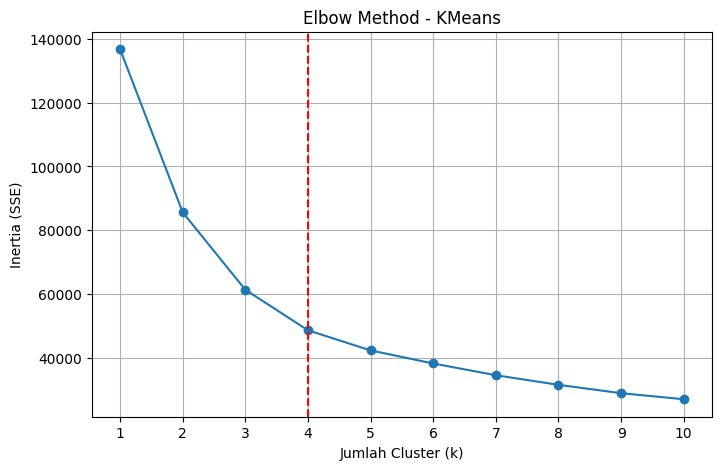

In [13]:
# X_scaled diasumsikan sudah dinormalisasi (misalnya hasil StandardScaler)
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # inertia = within-cluster sum of squares

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method - KMeans")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia (SSE)")
plt.axvline(4, 0, 10000, color='red', linestyle='--')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**KMEANS**

In [14]:
from scipy.spatial.distance import cdist

In [15]:
# Clustering dengan KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hitung jarak setiap titik ke centroid-nya
centroids = kmeans.cluster_centers_
distances = np.min(cdist(X_scaled, centroids, metric='euclidean'), axis=1)

# Threshold berdasarkan persentil
threshold = np.percentile(distances, 95)  # ambil 5% terjauh sebagai outlier

# Buat DataFrame hasil
df_kmeans = df.copy()
df_kmeans['kmeans_cluster'] = kmeans_labels
df_kmeans['kmeans_distance'] = distances
df_kmeans['kmeans_outlier'] = distances > threshold

# Evaluasi
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("KMeans Silhouette Score:", round(kmeans_silhouette, 3))
print("KMeans - Jumlah outlier (threshold-based):", df_kmeans['kmeans_outlier'].sum())

KMeans Silhouette Score: 0.348
KMeans - Jumlah outlier (threshold-based): 1140


**DBSCAN**

In [16]:
# Clustering dengan DBSCAN
dbscan = DBSCAN()
dbscan_labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['dbscan_cluster'] = dbscan_labels
df_dbscan['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_dbscan['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")

DBSCAN - Jumlah cluster: 4
DBSCAN - Jumlah outlier: 102
DBSCAN Silhouette Score: 0.014


In [17]:
df_dbscan['created_at'] = pd.to_datetime(df_dbscan['created_at'])

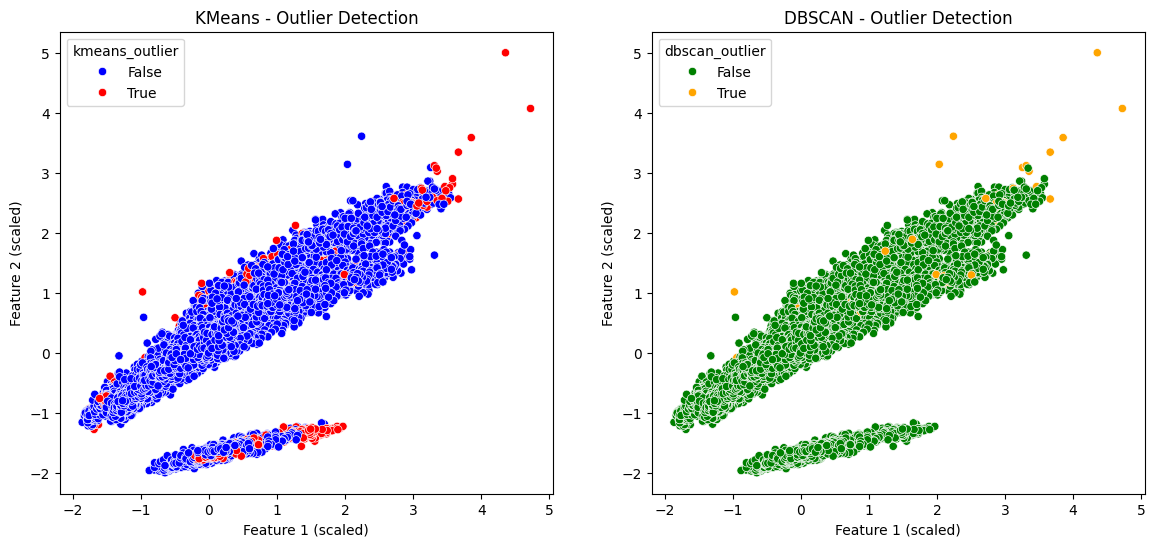

In [18]:
plt.figure(figsize=(14, 6))

# Visualisasi KMeans
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 4], y=X_scaled[:, 5],
                hue=df_kmeans['kmeans_outlier'],
                palette={False: 'blue', True: 'red'})
plt.title('KMeans - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

# Visualisasi DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_scaled[:, 4], y=X_scaled[:, 5],
                hue=df_dbscan['dbscan_outlier'],
                palette={False: 'green', True: 'orange'})
plt.title('DBSCAN - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

# plt.tight_layout()
plt.show()


**Hyperparameter Tuning untuk DBSCAN**

In [19]:
from tqdm.notebook import tqdm

best_k = None
best_score_k = -1
silhouette_scores_k = []

print("Grid Search KMeans:")
for k in tqdm(range(2, 10)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_k.append((k, score))
    
    if score > best_score_k:
        best_k = k
        best_score_k = score

print(f"Best K: {best_k}, Silhouette Score: {round(best_score_k, 4)}")

Grid Search KMeans:


  0%|          | 0/8 [00:00<?, ?it/s]

Best K: 4, Silhouette Score: 0.3476


### Grid Search DBSCAN dengan Evaluasi Silhouette Score dan Coefficient Correlation (CC)

Untuk memilih kombinasi parameter `eps` dan `min_samples` yang optimal pada algoritma DBSCAN, digunakan dua metrik evaluasi:

- **Silhouette Score**: Mengukur kualitas pemisahan cluster.
- **Coefficient Correlation (CC)**: Rasio antara kepadatan input (min_samples × eps) terhadap jumlah cluster hasil DBSCAN, dihitung dengan rumus:

$$
\text{CC} = \frac{\text{min\_samples} \times \text{eps}}{\text{n\_clusters} \times 10}
$$

Rumus CC tersebut diadaptasi dari:

> Saeedi, H. & Hossein, H. (2017). *A Novel Anomaly Detection Algorithm Using DBSCAN and SVM in Wireless Sensor Networks*,  
> *International Journal of Advanced Computer Science and Applications (IJACSA)*, 8(4), 254–262.

Tujuan dari penggunaan CC adalah untuk mendapatkan konfigurasi DBSCAN yang **stabil, efisien**, dan **tidak overfitting** terhadap noise, terutama dalam konteks deteksi fault pada data sensor.

In [20]:
# === Grid search range ===
eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = range(3, 15)

results = []

for eps in tqdm(eps_values):
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Hitung silhouette hanya jika jumlah cluster valid
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1

        # Hitung Coefficient Correlation (CC) hanya jika n_clusters > 0
        cc = (min_samples * eps / (n_clusters * 10)) if n_clusters > 0 else np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': score,
            'cc': cc
        })

# === Simpan sebagai DataFrame ===
results_df = pd.DataFrame(results)

  0%|          | 0/17 [00:00<?, ?it/s]

In [21]:
# Filter: minimal 2 cluster & score valid
valid_results = results_df[(results_df['n_clusters'] >= 2) & (results_df['silhouette_score'] > 0)]

# Urutkan berdasarkan kombinasi terbaik: silhouette tinggi + cc kecil
best = valid_results.sort_values(by=['cc', 'silhouette_score'], ascending=[True, False])
print("Top kombinasi parameter terbaik (berdasarkan jurnal):")
print(best.head(10))

Top kombinasi parameter terbaik (berdasarkan jurnal):
    eps  min_samples  n_clusters  n_noise  silhouette_score        cc
48  0.7            3           5       24          0.040464  0.042000
60  0.8            3           4       18          0.040027  0.060000
26  0.5            5           4      102          0.013983  0.062500
72  0.9            3           4       15          0.039941  0.067500
49  0.7            4           4       27          0.061548  0.070000
27  0.5            6           4      103          0.013974  0.075000
38  0.6            5           4       76          0.038045  0.075000
84  1.0            3           4       10          0.040212  0.075000
61  0.8            4           3       22          0.065370  0.106667
96  1.1            3           3        4          0.348565  0.110000


In [26]:
# Clustering dengan DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['dbscan_cluster'] = dbscan_labels
df_dbscan['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_dbscan['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")

DBSCAN - Jumlah cluster: 5
DBSCAN - Jumlah outlier: 24
DBSCAN Silhouette Score: 0.04


In [27]:
df_dbscan['created_at'] = pd.to_datetime(df_dbscan['created_at'])

In [28]:
df_dbscan = df_dbscan.set_index('created_at')

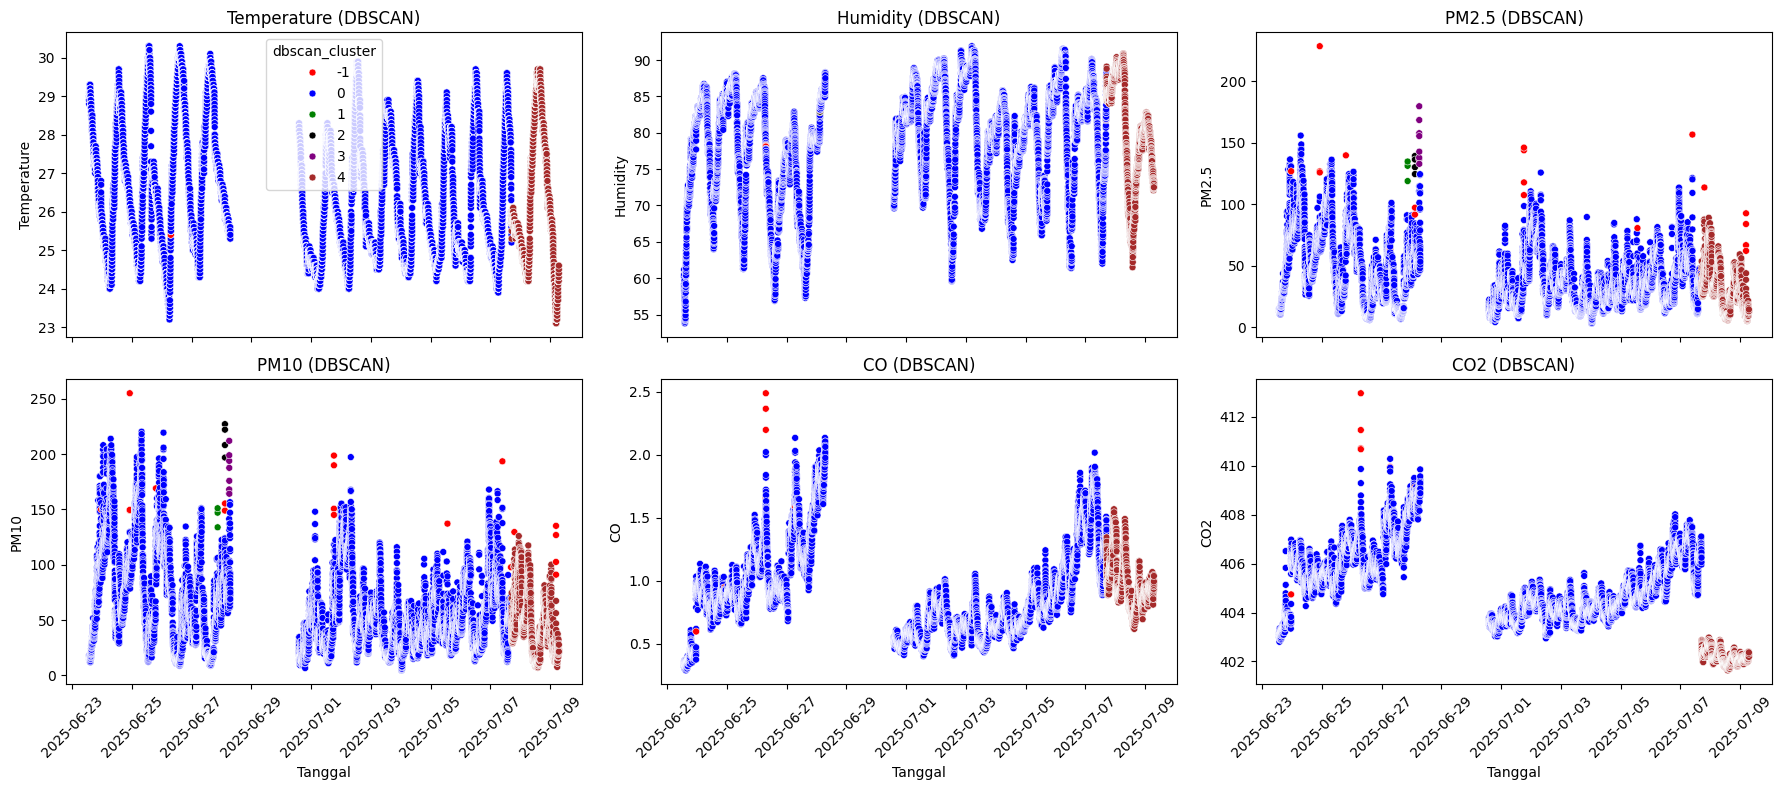

In [29]:
# Fitur yang ingin divisualisasikan
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']

# Setup subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

# Warna DBSCAN cluster
palette = {-1: 'red', 0: 'blue', 1: 'green', 2: 'black', 3: 'purple', 4: 'brown'}

# Loop per fitur
for i, feature in enumerate(features):
    ax = axes[i]
    sns.scatterplot(
        data=df_dbscan,
        x=df_dbscan.index,
        y=feature,
        hue='dbscan_cluster',
        palette=palette,
        s=25,
        ax=ax,
        legend=(i == 0)  # hanya legend di subplot pertama
    )
    ax.set_title(f'{feature} (DBSCAN)')
    ax.set_ylabel(feature)
    ax.set_xlabel('Tanggal')
    ax.tick_params(axis='x', rotation=45)

# Layout rapi
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.tight_layout()
plt.show()

In [30]:
df_dbscan

,Temperature,Humidity,PM2.5,PM10,CO,CO2,dbscan_cluster,dbscan_outlier
created_at,,,,,,,,
2025-06-23 13:34:08+07:00,28.8,61.2,15.0,18.1,0.34771,403.16486,0,False
2025-06-23 13:35:04+07:00,28.9,60.3,14.4,16.1,0.35701,403.10541,0,False
2025-06-23 13:35:56+07:00,28.9,60.2,12.7,15.9,0.32528,403.13834,0,False
2025-06-23 13:36:48+07:00,29.0,58.9,13.3,14.9,0.34200,403.03397,0,False
2025-06-23 13:37:41+07:00,29.0,59.1,13.5,15.1,0.32968,403.16486,0,False
...,...,...,...,...,...,...,...,...
2025-07-09 06:56:23+07:00,24.4,73.0,13.4,21.6,0.99821,402.23297,4,False
2025-07-09 06:57:12+07:00,24.6,72.7,13.0,22.4,0.99075,402.19568,4,False
2025-07-09 06:58:02+07:00,24.6,72.4,13.1,21.3,0.98333,402.18744,4,False


In [31]:
df_clean = df_dbscan[df_dbscan['dbscan_cluster'] != -1].copy()
df_clean.drop(columns=['dbscan_cluster', 'dbscan_outlier'], inplace=True)

In [32]:
df_clean

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-23 13:34:08+07:00,28.8,61.2,15.0,18.1,0.34771,403.16486
2025-06-23 13:35:04+07:00,28.9,60.3,14.4,16.1,0.35701,403.10541
2025-06-23 13:35:56+07:00,28.9,60.2,12.7,15.9,0.32528,403.13834
2025-06-23 13:36:48+07:00,29.0,58.9,13.3,14.9,0.34200,403.03397
2025-06-23 13:37:41+07:00,29.0,59.1,13.5,15.1,0.32968,403.16486
...,...,...,...,...,...,...
2025-07-09 06:56:23+07:00,24.4,73.0,13.4,21.6,0.99821,402.23297
2025-07-09 06:57:12+07:00,24.6,72.7,13.0,22.4,0.99075,402.19568
2025-07-09 06:58:02+07:00,24.6,72.4,13.1,21.3,0.98333,402.18744


In [ ]:
import joblib

# simpan model
joblib.dump(dbscan, 'fault_detection_dbscan.pkl')

['fault_detection_dbscan.pkl']

In [33]:
import os

# Ambil tanggal awal & akhir dari index
start_date = df_clean.index.min().strftime('%Y-%m-%d')
end_date = df_clean.index.max().strftime('%Y-%m-%d')

# Buat nama file
filename = f"clean_data_{start_date}_to_{end_date}.csv"

# Pastikan folder target ada (dari folder notebook ke folder proyek root)
os.makedirs("../data/processed", exist_ok=True)

# Simpan file ke direktori proyek (bukan dalam notebooks/)
df_clean.to_csv(f"../data/processed/{filename}", index=True)

print(f"File berhasil disimpan sebagai: ../data/processed/{filename}")

File berhasil disimpan sebagai: ../data/processed/clean_data_2025-06-23_to_2025-07-09.csv
